<a href="https://colab.research.google.com/github/aqwenaaa/Model-Comparison/blob/renald/Kuis_2_RenaldAgustinus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil dimuat!
✅ Data berhasil dibersihkan dan dikonversi ke angka.


,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description
0,176,0,0,50.0,0.0
1,3288,0,0,34.0,0.0
2,1786,0,0,18.9,0.0
3,1786,0,0,34.0,0.0
4,2778,0,0,50.0,0.0


✅ Berhasil! Dataset AXA-PRISM sudah terhitung tanpa error.

--- ANALISIS PERBANDINGAN TOP 10 ---


,Urutan,SAW,EDAS,TOPSIS,Similiar_SAW_EDAS
0,1,4060,4060,4060,True
1,2,4060,4060,4060,True
2,3,3971,3971,3971,True
3,4,3971,3971,3971,True
4,5,3973,3973,3973,True
5,6,3935,3935,3935,True
6,7,4001,3894,3944,False
7,8,3894,4001,3894,False
8,9,3944,3944,4001,True
9,10,3895,3895,3895,True



Statistik Kemiripan (SAW vs EDAS):
Data Berbeda: 2 alternatif
Persentase Perbedaan: 20.0%


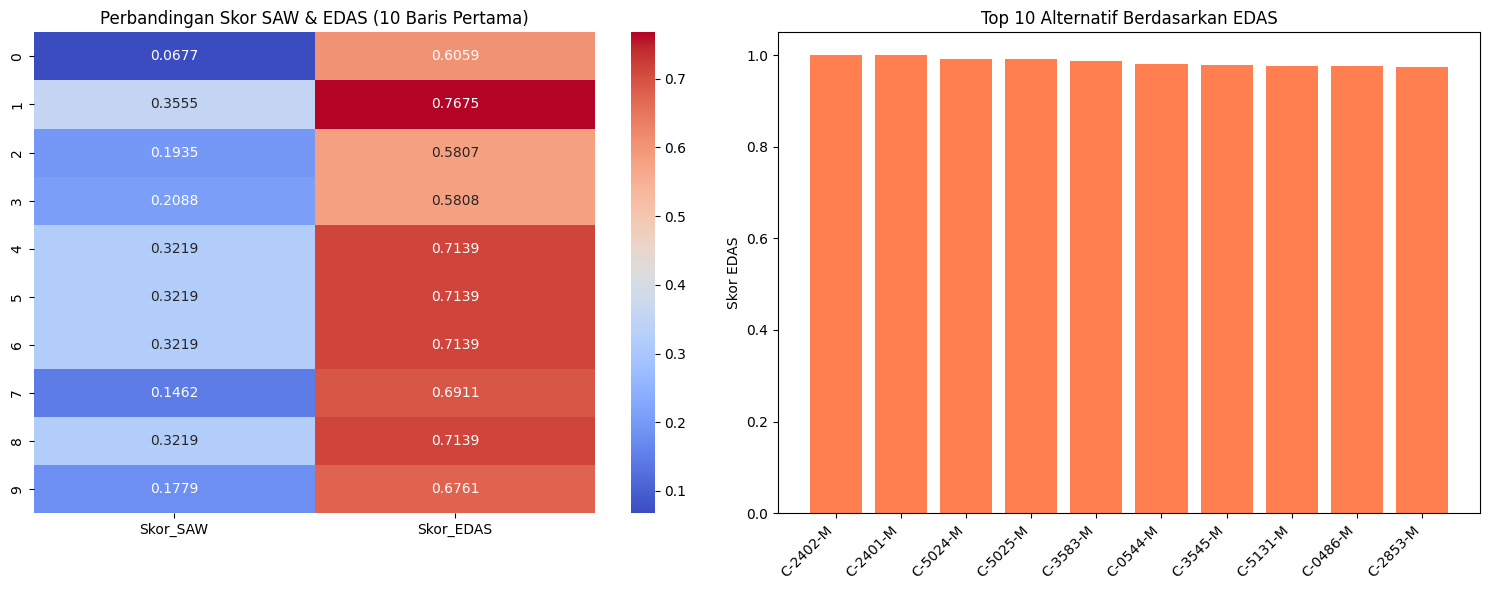


Proses selesai. File final disimpan di: /content/drive/MyDrive/Hasil_Analisis_AXA_PRISM.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# --- STEP 1: MOUNT GOOGLE DRIVE & IMPORT DATASET ---
# Ini akan memunculkan popup untuk memberikan izin akses ke Google Drive
drive.mount('/content/drive')

# UBAH PATH INI SESUAI DENGAN LOKASI FILE CSV-MU DI GOOGLE DRIVE
# Contoh: '/content/drive/MyDrive/Kuis2/Data_Klaim.csv'
file_path = '/content/drive/MyDrive/Dataset/Data_Klaim.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat!")
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path {file_path}. Pastikan path sudah benar.")

# --- STEP 2: KONFIGURASI & PEMBERSIHAN DATA ---

# 1. Pilih kolom kriteria (1 sampai 5)
cols_kriteria = df.columns[1:6]

# 2. Fungsi pembersihan karakter non-numerik (Rp, spasi, koma, dll)
for col in cols_kriteria:
    if df[col].dtype == 'object': # Jika kolom terbaca sebagai teks
        df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
        # Jika string kosong setelah dibersihkan, isi dengan 0
        df[col] = df[col].replace('', '0')
        # Konversi ke float
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3. Pastikan matriks bertipe float agar bisa dihitung
matrix = df[cols_kriteria].values.astype(float)

# 4. Konfigurasi Bobot & Tipe
weights = np.array([0.40, 0.20, 0.20, 0.10, 0.10])
criteria_types = ['benefit', 'benefit', 'benefit', 'benefit', 'cost']

print("✅ Data berhasil dibersihkan dan dikonversi ke angka.")
display(df[cols_kriteria].head())

# --- STEP 3: FUNGSI ALGORITMA (SAFE VERSION) ---

def calculate_saw(matrix, weights, types):
    norm_matrix = np.zeros_like(matrix, dtype=float)
    for j in range(matrix.shape[1]):
        col_max = np.max(matrix[:, j])
        col_min = np.min(matrix[:, j])
        if types[j] == 'benefit':
            # Jika max = 0, biarkan kolom tetap 0 untuk menghindari pembagian dengan nol
            if col_max > 0:
                norm_matrix[:, j] = matrix[:, j] / col_max
        else:
            # Untuk cost: hindari pembagian dengan nol pada tiap elemen
            # Gunakan np.where untuk membagi hanya jika nilai > 0
            norm_matrix[:, j] = np.divide(col_min, matrix[:, j], out=np.zeros_like(matrix[:, j]), where=matrix[:, j]!=0)
    return np.dot(norm_matrix, weights)

def calculate_edas(matrix, weights, types):
    avg_sol = np.mean(matrix, axis=0)
    pda = np.zeros_like(matrix, dtype=float)
    nda = np.zeros_like(matrix, dtype=float)

    for j in range(matrix.shape[1]):
        divisor = avg_sol[j] if avg_sol[j] != 0 else 1 # Hindari pembagian nol
        if types[j] == 'benefit':
            pda[:, j] = np.maximum(0, (matrix[:, j] - avg_sol[j])) / divisor
            nda[:, j] = np.maximum(0, (avg_sol[j] - matrix[:, j])) / divisor
        else:
            pda[:, j] = np.maximum(0, (avg_sol[j] - matrix[:, j])) / divisor
            nda[:, j] = np.maximum(0, (matrix[:, j] - avg_sol[j])) / divisor

    sp, sn = np.dot(pda, weights), np.dot(nda, weights)

    # Penanganan pembagian dengan nol pada skor normalisasi
    max_sp = np.max(sp)
    max_sn = np.max(sn)
    nsp = sp / max_sp if max_sp != 0 else sp
    nsn = 1 - (sn / max_sn) if max_sn != 0 else 1 - sn
    return (nsp + nsn) / 2

def calculate_topsis(matrix, weights, types):
    # Normalisasi: hindari pembagian jika sum of squares = 0
    norm_denom = np.sqrt((matrix**2).sum(axis=0))
    norm_matrix = np.divide(matrix, norm_denom, out=np.zeros_like(matrix), where=norm_denom!=0)

    weighted_matrix = norm_matrix * weights
    ideal_pos = [np.max(weighted_matrix[:, j]) if types[j] == 'benefit' else np.min(weighted_matrix[:, j]) for j in range(matrix.shape[1])]
    ideal_neg = [np.min(weighted_matrix[:, j]) if types[j] == 'benefit' else np.max(weighted_matrix[:, j]) for j in range(matrix.shape[1])]

    dist_pos = np.sqrt(((weighted_matrix - ideal_pos)**2).sum(axis=1))
    dist_neg = np.sqrt(((weighted_matrix - ideal_neg)**2).sum(axis=1))

    # Menghindari pembagian dengan nol pada preferensi relatif
    total_dist = dist_pos + dist_neg
    return np.divide(dist_neg, total_dist, out=np.zeros_like(dist_neg), where=total_dist!=0)

# --- STEP 4: EKSEKUSI & RANKING (SAFE FROM NaN) ---

# Hitung Skor
df['Skor_SAW'] = calculate_saw(matrix, weights, criteria_types)
df['Skor_EDAS'] = calculate_edas(matrix, weights, criteria_types)
df['Skor_TOPSIS'] = calculate_topsis(matrix, weights, criteria_types)

# Bersihkan hasil NaN sebelum di-ranking agar tidak error saat .astype(int)
df[['Skor_SAW', 'Skor_EDAS', 'Skor_TOPSIS']] = df[['Skor_SAW', 'Skor_EDAS', 'Skor_TOPSIS']].fillna(0)

# Ranking
df['Rank_SAW'] = df['Skor_SAW'].rank(ascending=False).astype(int)
df['Rank_EDAS'] = df['Skor_EDAS'].rank(ascending=False).astype(int)
df['Rank_TOPSIS'] = df['Skor_TOPSIS'].rank(ascending=False).astype(int)

print("✅ Berhasil! Dataset AXA-PRISM sudah terhitung tanpa error.")
# --- STEP 5: ANALISIS PERBANDINGAN TOP 10 (REVISI AMAN) ---

# Ambil 10 data teratas untuk tiap metode dengan cara di-sortir (menghindari error rank yang hilang)
# Kita ambil kolom 'Nomor Polis' sebagai pengenal alternatifnya
top_saw = df.sort_values(by='Skor_SAW', ascending=False).head(10)['Nomor Polis'].values
top_edas = df.sort_values(by='Skor_EDAS', ascending=False).head(10)['Nomor Polis'].values
top_topsis = df.sort_values(by='Skor_TOPSIS', ascending=False).head(10)['Nomor Polis'].values

# Buat DataFrame perbandingan langsung dari array hasil sortir
comp_df = pd.DataFrame({
    'Urutan': range(1, 11),
    'SAW': top_saw,
    'EDAS': top_edas,
    'TOPSIS': top_topsis
})

# Cek kemiripan antara SAW dan EDAS
comp_df['Similiar_SAW_EDAS'] = comp_df['SAW'] == comp_df['EDAS']

diff_count = 10 - comp_df['Similiar_SAW_EDAS'].sum()
percentage_diff = (diff_count / 10) * 100

print(f"\n--- ANALISIS PERBANDINGAN TOP 10 ---")
display(comp_df)

print(f"\nStatistik Kemiripan (SAW vs EDAS):")
print(f"Data Berbeda: {diff_count} alternatif")
print(f"Persentase Perbedaan: {percentage_diff}%")
# --- STEP 6: VISUALISASI KEPUTUSAN ---
plt.figure(figsize=(15, 6))

# Visualisasi 1: Heatmap Tabel Keputusan SAW & EDAS
plt.subplot(1, 2, 1)
# Mengambil 10 data teratas berdasarkan urutan dataset awal (bukan urutan ranking)
sns.heatmap(df[['Skor_SAW', 'Skor_EDAS']].head(10), annot=True, cmap='coolwarm', fmt=".4f")
plt.title("Perbandingan Skor SAW & EDAS (10 Baris Pertama)")

# Visualisasi 2: Bar Chart Top 10 EDAS
plt.subplot(1, 2, 2)
df_plot = df.sort_values('Rank_EDAS').head(10)
plt.bar(df_plot.iloc[:, 0], df_plot['Skor_EDAS'], color='coral')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Alternatif Berdasarkan EDAS")
plt.ylabel("Skor EDAS")

plt.tight_layout()
plt.show()

# --- STEP 7: SIMPAN HASIL KE GOOGLE DRIVE ---
output_path = '/content/drive/MyDrive/Hasil_Analisis_AXA_PRISM.csv'
df.to_csv(output_path, index=False)
print(f"\nProses selesai. File final disimpan di: {output_path}")